In [2]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading}  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (i)x^2)
f_3(x) = a1  (x + (i/3)x^3)
f_4(x) = a0  (1 + (2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (3*i)x^2 + (-1)x^4 + (-i/15)x^6)
f_7(x) = a1  (x + (i)x^3 + (-1/5)x^5 + (-i/105)x^7)


In [3]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    return (f"f_{N}({var}) = {leading_name}  (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=-1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=-1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (-i)x^2)
f_3(x) = a1  (x + (-i/3)x^3)
f_4(x) = a0  (1 + (-2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (-2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (-3*i)x^2 + (-1)x^4 + (i/15)x^6)
f_7(x) = a1  (x + (-i)x^3 + (-1/5)x^5 + (i/105)x^7)


In [4]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (i)x^2 + (-1/5)x^4 + (-i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [5]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (-i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (-2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (-i)x^2 + (-1/5)x^4 + (i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [ ]:
import subprocess
import sys

def install_full_scientific_stack():
    # lista completa integrando tus requerimientos y herramientas de gpu
    packages = [
        # nucleo cientifico y matematico
        "numpy", 
        "scipy", 
        "sympy",
        "numba",
        "cupy-cuda12x",   # aceleracion por gpu
        
        # analisis de datos y estadistica
        "pandas", 
        "scikit-learn", 
        "statsmodels",
        
        # visualizacion
        "matplotlib", 
        "seaborn", 
        "plotly",
        
        # infraestructura jupyter y utilidades
        "jupyterlab", 
        "notebook", 
        "ipykernel",
        "tqdm",
        
        # manejo de archivos y formatos
        "openpyxl", 
        "xlrd", 
        "pyarrow"
    ]
    
    print("iniciando instalacion del stack cientifico completo...")
    
    for package in packages:
        try:
            print(f"instalando {package}...")
            # se usa --upgrade para asegurar las versiones mas recientes y estables
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package])
        except subprocess.CalledProcessError:
            print(f"error al instalar {package}. revisa la version de cuda o tu conexion.")

if __name__ == "__main__":
    install_full_scientific_stack()

: 

In [ ]:
import subprocess
import sys

def install_full_scientific_stack():
    # lista completa integrando tus requerimientos y herramientas de gpu
    packages = [
        # nucleo cientifico y matematico
        "numpy", 
        "scipy", 
        "sympy",
        "numba",
        "cupy-cuda12x",   # aceleracion por gpu
        
        # analisis de datos y estadistica
        "pandas", 
        "scikit-learn", 
        "statsmodels",
        
        # visualizacion
        "matplotlib", 
        "seaborn", 
        "plotly",
        
        # infraestructura jupyter y utilidades
        "jupyterlab", 
        "notebook", 
        "ipykernel",
        "tqdm",
        
        # manejo de archivos y formatos
        "openpyxl", 
        "xlrd", 
        "pyarrow"
    ]
    
    print("iniciando instalacion del stack cientifico completo...")
    
    for package in packages:
        try:
            print(f"instalando {package}...")
            # se usa --upgrade para asegurar las versiones mas recientes y estables
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package])
        except subprocess.CalledProcessError:
            print(f"error al instalar {package}. revisa la version de cuda o tu conexion.")

if __name__ == "__main__":
    install_full_scientific_stack()

iniciando instalacion del stack cientifico completo...
instalando numpy...
instalando scipy...
instalando sympy...
instalando numba...


Polinomios asociados a la ec. hipergeometrica confluente

In [6]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(0, N):  # paso 1
        num = -(s*(s-1) + s + sp.Rational(3,4) - 2*sp.I*((N*(N-1)) + N+ sp.Rational(3,4)))
        den = (s + 1)
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1 + -3/4 + 7*i/2u^1)
f_2(u) = a0  (1 + -3/4 + 19*i/2u^1 + -1423/32 - 95*i/8u^2)
f_3(u) = a0  (1 + -3/4 + 39*i/2u^1 + -6063/32 - 195*i/8u^2 + 58679/128 - 76349*i/64u^3)
f_4(u) = a0  (1 + -3/4 + 67*i/2u^1 + -17935/32 - 335*i/8u^2 + 520325/384 - 396305*i/64u^3 + 99445515/2048 + 20307365*i/768u^4)
f_5(u) = a0  (1 + -3/4 + 103*i/2u^1 + -42415/32 - 515*i/8u^2 + 1230245/384 - 1449725*i/64u^3 + 581293515/2048 + 74083265*i/768u^4 + -47785843447/24576 + 31953076223*i/12288u^5)
f_6(u) = a0  (1 + -3/4 + 147*i/2u^1 + -86415/32 - 735*i/8u^2 + 835415/128 - 4225025*i/64u^3 + 2451733515/2048 + 71895495*i/256u^4 + -66672869949/8192 + 68227366809*i/4096u^5 + -11083462026315/65536 - 2804721777305*i/16384u^6)
f_7(u) = a0  (1 + -3/4 + 199*i/2u^1 + -158383/32 - 995*i/8u^2 + 4593317/384 - 10493469*i/64u^3 + 8293088203/2048 + 535451489*i/768u^4 + -3371788269779/122880 + 4807472658139*i/61440u^5 + -3479454044091407/2949120 - 64786419415241*i/81920u^6 + 47991

In [ ]:
import subprocess
import sys

def install_full_scientific_stack():
    # lista completa integrando tus requerimientos y herramientas de gpu
    packages = [
        # nucleo cientifico y matematico
        "numpy", 
        "scipy", 
        "sympy",
        "numba",
        "cupy-cuda12x",   # aceleracion por gpu
        
        # analisis de datos y estadistica
        "pandas", 
        "scikit-learn", 
        "statsmodels",
        
        # visualizacion
        "matplotlib", 
        "seaborn", 
        "plotly",
        
        # infraestructura jupyter y utilidades
        "jupyterlab", 
        "notebook", 
        "ipykernel",
        "tqdm",
        
        # manejo de archivos y formatos
        "openpyxl", 
        "xlrd", 
        "pyarrow"
    ]
    
    print("iniciando instalacion del stack cientifico completo...")

    
    for package in packages:
        try:
            print(f"instalando {package}...")
            # se usa --upgrade para asegurar las versiones mas recientes y estables
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", package])
        except subprocess.CalledProcessError:
            print(f"error al instalar {package}. revisa la version de cuda o tu conexion.")

if __name__ == "__main__":
    install_full_scientific_stack()


In [7]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(1, N):  # paso 1
        num = -(s + sp.Rational(1,4) - 2*sp.I*((N + sp.Rational(1,4))))
        den = (s + 1) * s
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1)
f_2(u) = a0  (1)
f_3(u) = a0  (1)
f_4(u) = a0  (1)
f_5(u) = a0  (1)
f_6(u) = a0  (1)
f_7(u) = a0  (1)


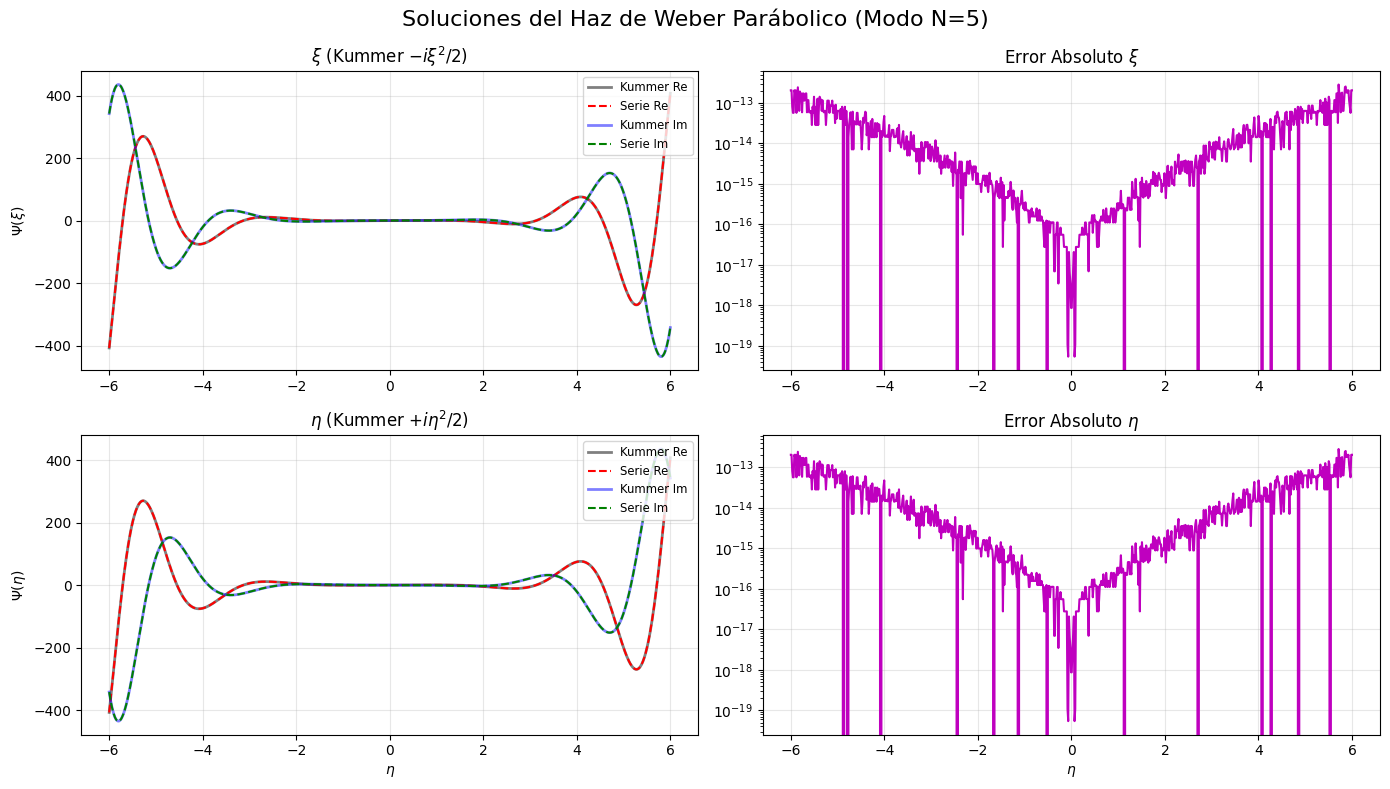

Parametro a (Weber): 5.5
Parametro A (Kummer par): -2.5
Ksi (ξ): rama par usa B=1/2; rama impar usa B=3/2 con factor ξ
Eta (η): rama par usa B=1/2; rama impar usa B=3/2 con factor η


In [8]:
import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt


def a_from_N_even(N: int) -> float:
    return 0.5*(2*N + 1)


def get_coeffs(N: int):
    c = [0j]*(2*N + 1)

    if N % 2 == 0:
        # Caso par: arranca en x^0
        c[0] = 1.0 + 0j
        c[1] = 0.0 + 0j
        rng = range(0, 2*N, 2)
    else:
        # Caso impar: arranca en x^1
        c[0] = 0.0 + 0j
        c[1] = 1.0 + 0j
        rng = range(1, 2*N-1, 2)

    for s in rng:
        num = -1j*(2*s + 1)/2.0 + 1j*(2*N + 1)/2.0
        den = (s + 2)*(s + 1)
        c[s+2] = (num/den)*c[s]

    return np.array(c, dtype=complex)

def series_even(x, N: int, beta_is_imag=True):
    x = np.asarray(x, dtype=float)
    c = get_coeffs(N)
    k = np.arange(len(c))[:, None]
    Xk = x[None, :] ** k
    poly = (c[:, None] * Xk).sum(axis=0)
    pref = np.exp((1j if beta_is_imag else 1.0) * 0.25 * x**2)
    return pref * poly


def kummer_xi_analytic(a_std: float, xi):
    xi = np.asarray(xi, dtype=float)

    # a_std = N + 1/2  =>  N = a_std - 1/2
    N_est = int(round(a_std - 0.5))

    if N_est % 2 == 0:
        # Par: M(A, 1/2, -i xi^2/2) * exp(+i xi^2/4)
        A = 0.25 - 0.5*a_std
        B = 0.5
        Z = -0.5j * xi**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return np.exp(0.25j * xi**2) * np.array(f(Z), dtype=complex)
    else:
        # Impar: xi * M(A+1/2, 3/2, -i xi^2/2) * exp(+i xi^2/4)
        A = 0.75 - 0.5*a_std   # = (0.25 - 0.5*a_std) + 1/2
        B = 1.5
        Z = -0.5j * xi**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return xi * np.exp(0.25j * xi**2) * np.array(f(Z), dtype=complex)

def kummer_eta_analytic(a_std: float, eta):
    eta = np.asarray(eta, dtype=float)

    N_est = int(round(a_std - 0.5))

    if N_est % 2 == 0:
        # Par: M(A, 1/2, +i eta^2/2) * exp(-i eta^2/4)
        A = 0.25 - 0.5*a_std
        B = 0.5
        Z = +0.5j * eta**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return np.exp(-0.25j * eta**2) * np.array(f(Z), dtype=complex)
    else:
        # Impar: eta * M(A+1/2, 3/2, +i eta^2/2) * exp(-i eta^2/4)
        A = 0.75 - 0.5*a_std
        B = 1.5
        Z = +0.5j * eta**2
        f = np.vectorize(lambda z: complex(mp.hyp1f1(A, B, z)))
        return eta * np.exp(-0.25j * eta**2) * np.array(f(Z), dtype=complex)


def comparar_componentes(N=6, span=(-6, 6), pts=800):
    a_std = a_from_N_even(N)
    u = np.linspace(span[0], span[1], pts)

    y_xi_num = series_even(u, N, beta_is_imag=True)
    y_xi_ana = kummer_xi_analytic(a_std, u)

    idx = len(u)//2
    if abs(y_xi_num[idx]) < 1e-14 or abs(y_xi_ana[idx]) < 1e-14:
        idx = min(idx + 1, len(u) - 1)

    scale_xi = y_xi_ana[idx] / y_xi_num[idx]
    y_xi_num_scaled = y_xi_num * scale_xi
    err_xi = np.abs(y_xi_ana - y_xi_num_scaled)

    y_eta_num = np.conj(series_even(u, N, beta_is_imag=True))
    y_eta_ana = kummer_eta_analytic(a_std, u)

    idx2 = len(u)//2
    if abs(y_eta_num[idx2]) < 1e-14 or abs(y_eta_ana[idx2]) < 1e-14:
        idx2 = min(idx2 + 1, len(u) - 1)

    scale_eta = y_eta_ana[idx2] / y_eta_num[idx2]
    y_eta_num_scaled = y_eta_num * scale_eta
    err_eta = np.abs(y_eta_ana - y_eta_num_scaled)

    # --- PLOT ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Soluciones del Haz de Weber Parábolico (Modo N={N})", fontsize=16)

    ax1 = axes[0, 0]
    ax1.set_title(r"$\xi$ (Kummer $-i\xi^2/2$)")
    ax1.plot(u, y_xi_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax1.plot(u, y_xi_num_scaled.real, 'r--', label="Serie Re")
    ax1.plot(u, y_xi_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax1.plot(u, y_xi_num_scaled.imag, 'g--', label="Serie Im")
    ax1.legend(loc='upper right', fontsize='small')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylabel(r"$\Psi(\xi)$")

    ax2 = axes[0, 1]
    ax2.set_title(r"Error Absoluto $\xi$")
    ax2.plot(u, err_xi, 'm')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.set_title(r"$\eta$ (Kummer $+i\eta^2/2$)")
    ax3.plot(u, y_eta_ana.real, 'k-', lw=2, alpha=0.5, label="Kummer Re")
    ax3.plot(u, y_eta_num_scaled.real, 'r--', label="Serie Re")
    ax3.plot(u, y_eta_ana.imag, 'b-', lw=2, alpha=0.5, label="Kummer Im")
    ax3.plot(u, y_eta_num_scaled.imag, 'g--', label="Serie Im")
    ax3.legend(loc='upper right', fontsize='small')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlabel(r"$\eta$")
    ax3.set_ylabel(r"$\Psi(\eta)$")

    ax4 = axes[1, 1]
    ax4.set_title(r"Error Absoluto $\eta$")
    ax4.plot(u, err_eta, 'm')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlabel(r"$\eta$")

    plt.tight_layout()
    plt.show()

    print(f"Parametro a (Weber): {a_std}")
    print(f"Parametro A (Kummer par): {0.25 - 0.5*a_std}")
    print(f"Ksi (ξ): rama par usa B=1/2; rama impar usa B=3/2 con factor ξ")
    print(f"Eta (η): rama par usa B=1/2; rama impar usa B=3/2 con factor η")

comparar_componentes(N=5, span=(-6, 6))


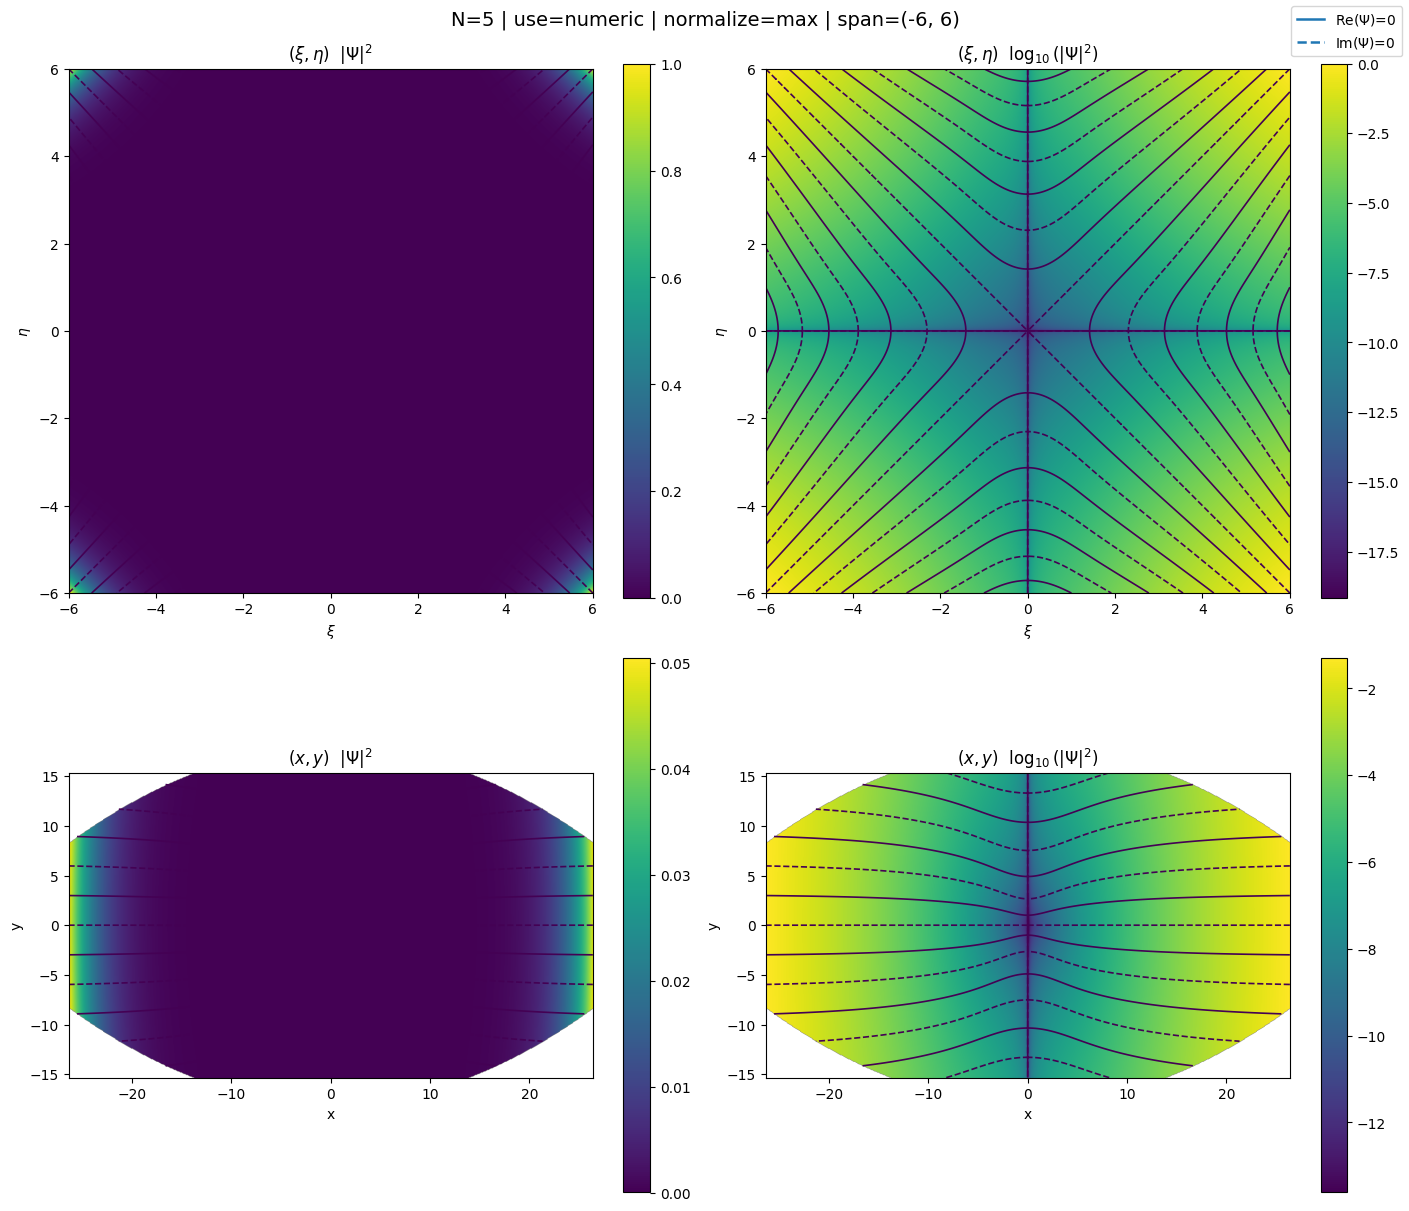

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _assert_required():
    need = ["a_from_N_even", "series_even", "kummer_xi_analytic", "kummer_eta_analytic"]
    miss = [n for n in need if n not in globals()]
 

def _scale_real_positive(s):
    return float(np.real(s * np.exp(-1j*np.angle(s))))

def normalize2d(PSI, x, y, mode="max"):
    if mode is None:
        return PSI
    I = np.abs(PSI)**2
    if mode == "max":
        m = I.max()
        return PSI/np.sqrt(m) if m > 0 else PSI
    if mode == "l2":
        dx = float(x[1]-x[0]); dy = float(y[1]-y[0])
        n2 = I.sum() * dx * dy
        return PSI/np.sqrt(n2) if n2 > 0 else PSI
    raise ValueError("mode must be 'max', 'l2', or None")

def build_PSI(N, span=(-6,6), pts=600, use="numeric", force_pos_scale=True):
    a = a_from_N_even(N)
    xi  = np.linspace(span[0], span[1], pts)
    eta = np.linspace(span[0], span[1], pts)

    if use == "analytic":
        psi_xi  = kummer_xi_analytic(a, xi)
        psi_eta = kummer_eta_analytic(a, eta)

    elif use == "numeric":
        # xi: serie escalada a la analítica
        yx_num = series_even(xi, N, beta_is_imag=True)
        yx_ana = kummer_xi_analytic(a, xi)
        idx = len(xi)//2
        if abs(yx_num[idx]) < 1e-14 or abs(yx_ana[idx]) < 1e-14:
            idx = min(idx+1, len(xi)-1)
        sxi = yx_ana[idx] / yx_num[idx]
        if force_pos_scale:
            sxi = _scale_real_positive(sxi)
        psi_xi = yx_num * sxi

        # eta: conj(serie) escalada a la analítica
        ye_num = np.conj(series_even(eta, N, beta_is_imag=True))
        ye_ana = kummer_eta_analytic(a, eta)
        idx2 = len(eta)//2
        if abs(ye_num[idx2]) < 1e-14 or abs(ye_ana[idx2]) < 1e-14:
            idx2 = min(idx2+1, len(eta)-1)
        seta = ye_ana[idx2] / ye_num[idx2]
        if force_pos_scale:
            seta = _scale_real_positive(seta)
        psi_eta = ye_num * seta

    else:
        raise ValueError("use must be 'numeric' or 'analytic'")

    PSI = psi_xi[:, None] * psi_eta[None, :]
    return xi, eta, PSI

def xy_map_from_xieta(xi, eta):
    XI, ETA = np.meshgrid(xi, eta, indexing="ij")
    X = XI * ETA
    Y = 0.5*(XI**2 - ETA**2)
    return X, Y

def interp_to_xy_grid(X, Y, F, xg, yg):
    # Intena SciPy griddata; si no, cae a binning simple
    Xf, Yf, Ff = X.ravel(), Y.ravel(), F.ravel()
    XG, YG = np.meshgrid(xg, yg, indexing="xy")

    try:
        from scipy.interpolate import griddata
        G = griddata(np.column_stack([Xf, Yf]), Ff, (XG, YG), method="cubic")
        # fallback dentro de SciPy si cubic deja NaNs
        if np.all(np.isnan(G)):
            G = griddata(np.column_stack([Xf, Yf]), Ff, (XG, YG), method="linear")
        return G
    except Exception:
        # binning 
        nx, ny = len(xg), len(yg)
        x_edges = np.linspace(xg[0], xg[-1], nx+1)
        y_edges = np.linspace(yg[0], yg[-1], ny+1)
        ix = np.digitize(Xf, x_edges) - 1
        iy = np.digitize(Yf, y_edges) - 1
        m = (ix>=0)&(ix<nx)&(iy>=0)&(iy<ny)
        ix, iy, Ff = ix[m], iy[m], Ff[m]
        flat = iy*nx + ix
        s = np.zeros(nx*ny); c = np.zeros(nx*ny)
        np.add.at(s, flat, Ff)
        np.add.at(c, flat, 1.0)
        out = np.full(nx*ny, np.nan)
        ok = c>0
        out[ok] = s[ok]/c[ok]
        return out.reshape(ny, nx)

def plot_xieta_and_xy(N=5, span=(-6,6), pts=700, xy_span=None, xy_res=600,
                      use="numeric", normalize="max", log_eps=1e-30, show_nodes=True):
    _assert_required()

    xi, eta, PSI = build_PSI(N, span=span, pts=pts, use=use, force_pos_scale=True)
    PSI = normalize2d(PSI, xi, eta, mode=normalize)

    # ----- (xi,eta) grids
    I_xieta = np.abs(PSI)**2
    Z_lin_xieta = I_xieta.T
    Z_log_xieta = np.log10(I_xieta + log_eps).T

    # ----- Map to (x,y) points
    X, Y = xy_map_from_xieta(xi, eta)

    # define xy window
    if xy_span is None:
        # usa percentiles para recortar outliers
        xmin, xmax = np.percentile(X, [2, 98])
        ymin, ymax = np.percentile(Y, [2, 98])
    else:
        xmin, xmax, ymin, ymax = xy_span

    xg = np.linspace(xmin, xmax, xy_res)
    yg = np.linspace(ymin, ymax, xy_res)

   
    Ig  = interp_to_xy_grid(X, Y, np.abs(PSI)**2, xg, yg)
    Reg = interp_to_xy_grid(X, Y, PSI.real,        xg, yg)
    Img = interp_to_xy_grid(X, Y, PSI.imag,        xg, yg)

    Z_lin_xy = Ig
    Z_log_xy = np.log10(Ig + log_eps)

  
    fig, ax = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

    # (xi,eta) no-log
    im00 = ax[0,0].imshow(Z_lin_xieta, origin="lower",
                          extent=(xi[0], xi[-1], eta[0], eta[-1]),
                          aspect="equal", interpolation="bilinear")
    ax[0,0].set_title(r"$(\xi,\eta)$  $|\Psi|^2$")
    ax[0,0].set_xlabel(r"$\xi$"); ax[0,0].set_ylabel(r"$\eta$")
    plt.colorbar(im00, ax=ax[0,0])

    # (xi,eta) log
    im01 = ax[0,1].imshow(Z_log_xieta, origin="lower",
                          extent=(xi[0], xi[-1], eta[0], eta[-1]),
                          aspect="equal", interpolation="bilinear")
    ax[0,1].set_title(r"$(\xi,\eta)$  $\log_{10}(|\Psi|^2)$")
    ax[0,1].set_xlabel(r"$\xi$"); ax[0,1].set_ylabel(r"$\eta$")
    plt.colorbar(im01, ax=ax[0,1])

    # (x,y) no-log
    im10 = ax[1,0].imshow(Z_lin_xy, origin="lower",
                          extent=(xmin, xmax, ymin, ymax),
                          aspect="equal", interpolation="bilinear")
    ax[1,0].set_title(r"$(x,y)$  $|\Psi|^2$")
    ax[1,0].set_xlabel("x"); ax[1,0].set_ylabel("y")
    plt.colorbar(im10, ax=ax[1,0])

    # (x,y) log
    im11 = ax[1,1].imshow(Z_log_xy, origin="lower",
                          extent=(xmin, xmax, ymin, ymax),
                          aspect="equal", interpolation="bilinear")
    ax[1,1].set_title(r"$(x,y)$  $\log_{10}(|\Psi|^2)$")
    ax[1,1].set_xlabel("x"); ax[1,1].set_ylabel("y")
    plt.colorbar(im11, ax=ax[1,1])

    # nodos
    if show_nodes:
        # en (xi,eta): contornos directos
        for axy in [ax[0,0], ax[0,1]]:
            axy.contour(xi, eta, PSI.real.T, levels=[0], linewidths=1.2, linestyles='-')
            axy.contour(xi, eta, PSI.imag.T, levels=[0], linewidths=1.2, linestyles='--')

        # en (x,y): contornos sobre grilla interpolada
        for axy in [ax[1,0], ax[1,1]]:
            axy.contour(xg, yg, Reg, levels=[0], linewidths=1.2, linestyles='-')
            axy.contour(xg, yg, Img, levels=[0], linewidths=1.2, linestyles='--')

        h1 = Line2D([0],[0], linestyle='-',  linewidth=1.8, label=r"Re($\Psi$)=0")
        h2 = Line2D([0],[0], linestyle='--', linewidth=1.8, label=r"Im($\Psi$)=0")
        fig.legend(handles=[h1,h2], loc="upper right")

    fig.suptitle(f"N={N} | use={use} | normalize={normalize} | span={span}", fontsize=14)
    plt.show()


plot_xieta_and_xy(N=5, span=(-6,6), pts=700, xy_res=600,
                  use="numeric", normalize="max", show_nodes=True)


  par-par (even, even): Re[ M(1/4 - i*n/2, 1/2, z_xi) ] * Re[ M(1/4 - i*m/2, 1/2, z_eta) ]
  par-impar (even, odd): Re[ M(1/4 - i*n/2, 1/2, z_xi) ] * Re[ xi * M(3/4 - i*m/2, 3/2, z_eta) ]
  impar-par (odd, even): Re[ xi * M(3/4 - i*n/2, 3/2, z_xi) ] * Re[ M(1/4 - i*m/2, 1/2, z_eta) ]
  impar-impar (odd, odd): Re[ xi * M(3/4 - i*n/2, 3/2, z_xi) ] * Re[ eta * M(3/4 - i*m/2, 3/2, z_eta) ]


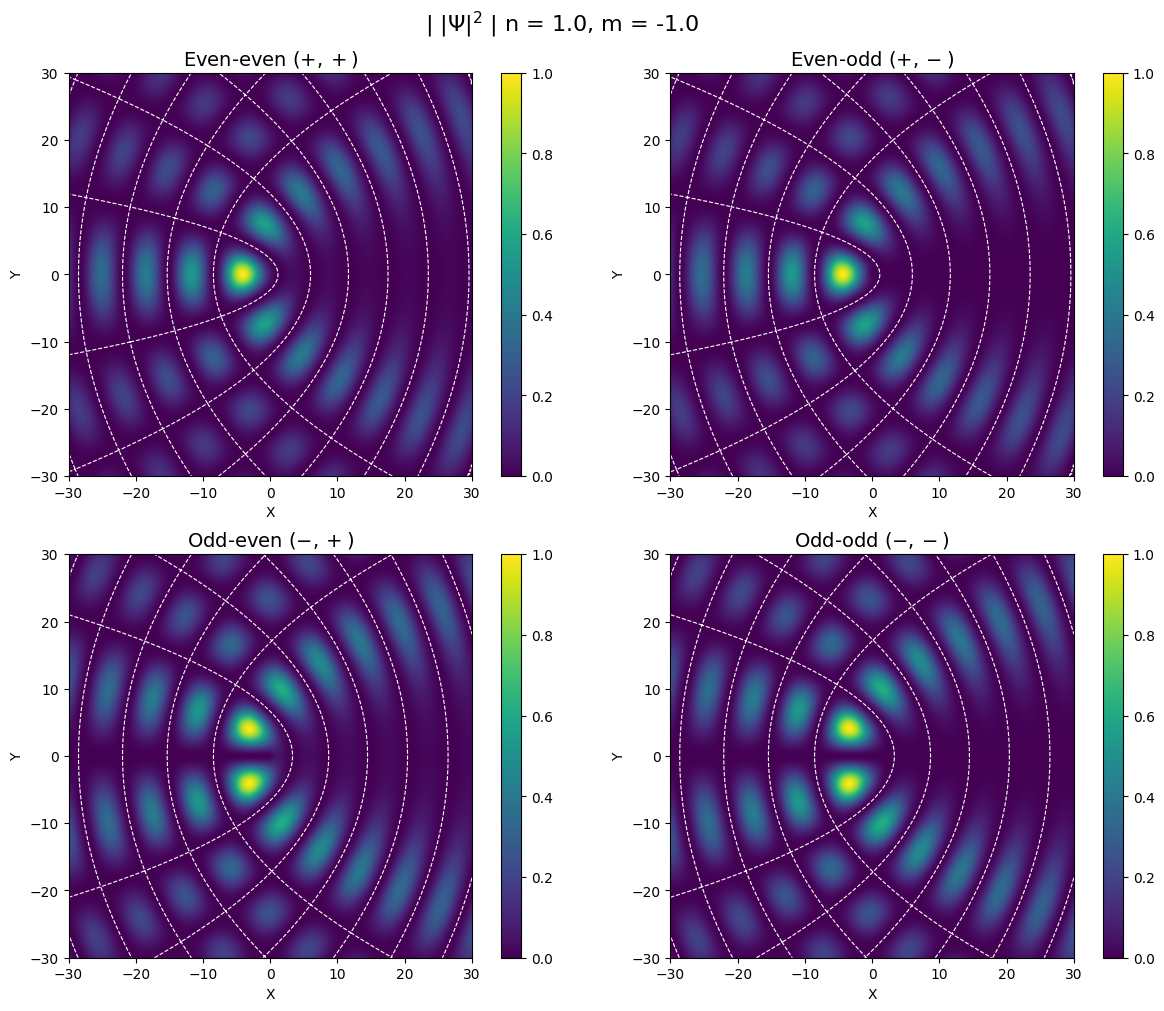

In [6]:
import cupy as cp
import matplotlib.pyplot as plt

def weber_even(q, x, max_iter=200, tol=1e-14):
    alpha = 0.25 - 0.5j * q
    beta = 0.5
    z = -0.5j * x**2
    
    term = cp.ones_like(z, dtype=cp.complex128)
    M = cp.ones_like(z, dtype=cp.complex128)
    
    for k in range(1, max_iter):
        term = term * (z * (alpha + k - 1) / (k * (beta + k - 1)))
        M += term
        if cp.max(cp.abs(term)) < tol:
            break
            
    X = cp.exp(0.25j * x**2) * M
    return X

def weber_odd(q, x, max_iter=200, tol=1e-14):
    alpha = 0.75 - 0.5j * q
    beta = 1.5
    z = -0.5j * x**2
    
    term = cp.ones_like(z, dtype=cp.complex128)
    M = cp.ones_like(z, dtype=cp.complex128)
    
    for k in range(1, max_iter):
        term = term * (z * (alpha + k - 1) / (k * (beta + k - 1)))
        M += term
        if cp.max(cp.abs(term)) < tol:
            break
            
    X = x * cp.exp(0.25j * x**2) * M
    return X

def build_weber_physical(n, m, parity_xi, parity_eta, x_span=(-30, 30), y_span=(-30, 30), pts=600):
    x = cp.linspace(x_span[0], x_span[1], pts)
    y = cp.linspace(y_span[0], y_span[1], pts)
    X, Y = cp.meshgrid(x, y, indexing="xy")
    
    R = cp.sqrt(X**2 + Y**2)
    XI = cp.sqrt(R + X)
    ETA = cp.sqrt(R - X)
    
    f_xi = weber_even if parity_xi == 'even' else weber_odd
    f_eta = weber_even if parity_eta == 'even' else weber_odd
    
    PSI = cp.real(f_xi(n, XI)) * cp.real(f_eta(m, ETA))
    return x, y, PSI

def plot_weber_parities(n=1.0, m=-1.0, pts_phys=800):
    print("  par-par (even, even): Re[ M(1/4 - i*n/2, 1/2, z_xi) ] * Re[ M(1/4 - i*m/2, 1/2, z_eta) ]")
    print("  par-impar (even, odd): Re[ M(1/4 - i*n/2, 1/2, z_xi) ] * Re[ xi * M(3/4 - i*m/2, 3/2, z_eta) ]")
    print("  impar-par (odd, even): Re[ xi * M(3/4 - i*n/2, 3/2, z_xi) ] * Re[ M(1/4 - i*m/2, 1/2, z_eta) ]")
    print("  impar-impar (odd, odd): Re[ xi * M(3/4 - i*n/2, 3/2, z_xi) ] * Re[ eta * M(3/4 - i*m/2, 3/2, z_eta) ]")

    parities = [
        ('even', 'even', r"Even-even $(+,+)$"),
        ('even', 'odd', r"Even-odd $(+,-)$"),
        ('odd', 'even', r"Odd-even $(-,+)$"),
        ('odd', 'odd', r"Odd-odd $(-,-)$")
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes = axes.flatten()
    
    for ax, (pxi, peta, title) in zip(axes, parities):
        x, y, PSI_phys = build_weber_physical(n, m, pxi, peta, pts=pts_phys)
        PSI_phys = PSI_phys / cp.max(cp.abs(PSI_phys))
        I_phys = cp.abs(PSI_phys)**2
        
        x_cpu = x.get()
        y_cpu = y.get()
        I_phys_cpu = I_phys.get()
        PSI_phys_cpu = PSI_phys.get()
        
        im = ax.imshow(I_phys_cpu, origin="lower", extent=(x_cpu[0], x_cpu[-1], y_cpu[0], y_cpu[-1]), aspect="equal")
        ax.contour(x_cpu, y_cpu, PSI_phys_cpu, levels=[0], colors='white', linewidths=0.8, linestyles='--')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
    fig.suptitle(rf" | $|\Psi|^2$ | n = {n}, m = {m}", fontsize=16)
    plt.show()

plot_weber_parities(n=1.0, m=-1.0)

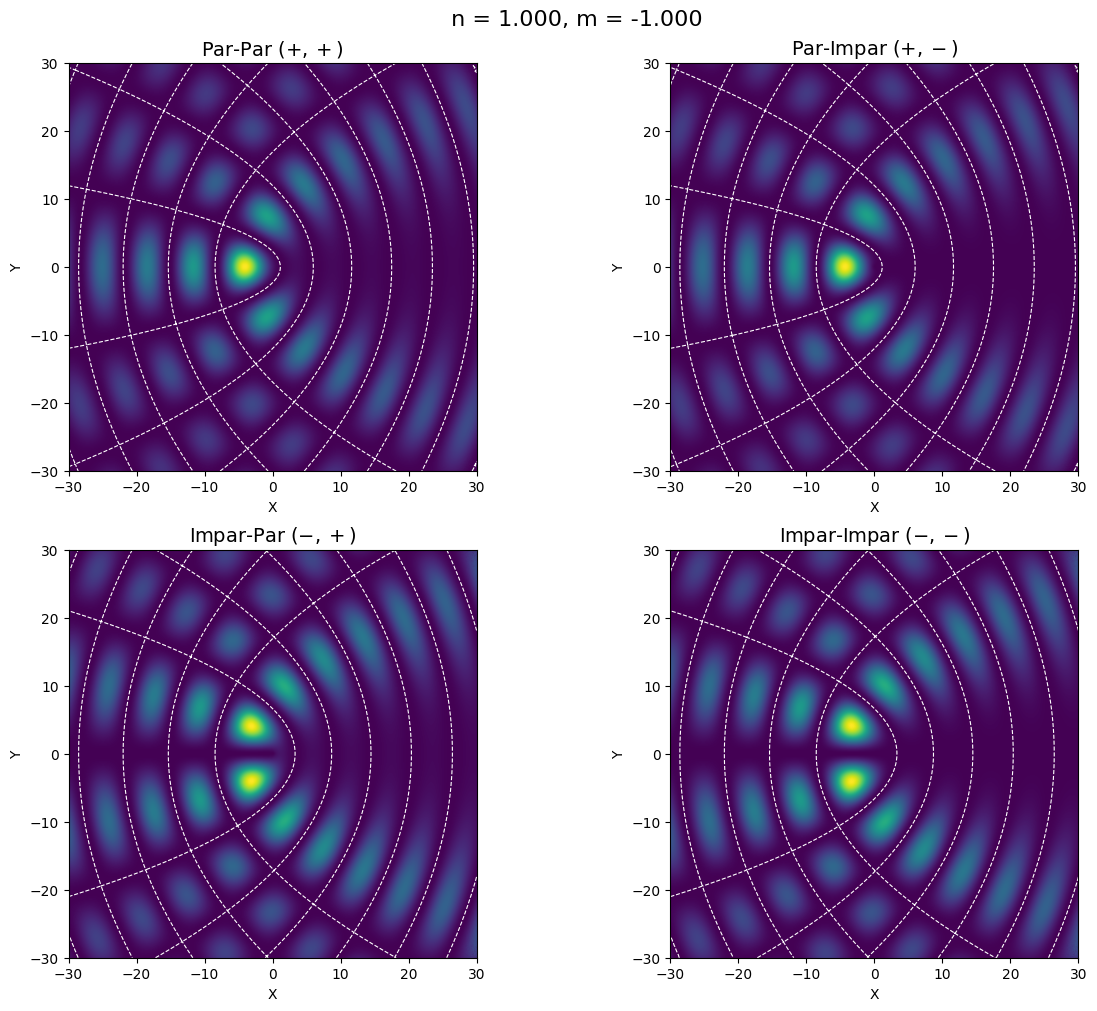

In [7]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def weber_even(q, x, max_iter=200, tol=1e-14):
    alpha = 0.25 - 0.5j * q
    beta = 0.5
    z = -0.5j * x**2
    
    term = cp.ones_like(z, dtype=cp.complex128)
    M = cp.ones_like(z, dtype=cp.complex128)
    
    for k in range(1, max_iter):
        term = term * (z * (alpha + k - 1) / (k * (beta + k - 1)))
        M += term
        if cp.max(cp.abs(term)) < tol:
            break
            
    X = cp.exp(0.25j * x**2) * M
    return X

def weber_odd(q, x, max_iter=200, tol=1e-14):
    alpha = 0.75 - 0.5j * q
    beta = 1.5
    z = -0.5j * x**2
    
    term = cp.ones_like(z, dtype=cp.complex128)
    M = cp.ones_like(z, dtype=cp.complex128)
    
    for k in range(1, max_iter):
        term = term * (z * (alpha + k - 1) / (k * (beta + k - 1)))
        M += term
        if cp.max(cp.abs(term)) < tol:
            break
            
    X = x * cp.exp(0.25j * x**2) * M
    return X

def build_weber_physical(n, m, parity_xi, parity_eta, x_span=(-30, 30), y_span=(-30, 30), pts=400):
    x = cp.linspace(x_span[0], x_span[1], pts)
    y = cp.linspace(y_span[0], y_span[1], pts)
    X, Y = cp.meshgrid(x, y, indexing="xy")
    
    R = cp.sqrt(X**2 + Y**2)
    XI = cp.sqrt(R + X)
    ETA = cp.sqrt(R - X)
    
    f_xi = weber_even if parity_xi == 'even' else weber_odd
    f_eta = weber_even if parity_eta == 'even' else weber_odd
    
    PSI = cp.real(f_xi(n, XI)) * cp.real(f_eta(m, ETA))
    return x, y, PSI

def animate_weber_evolution(frames=600, fps=60, pts_phys=400):
    n_vals = np.linspace(-1.0, 1.0, frames)
    m_vals = np.linspace(1.0, -1.0, frames)
    
    parities = [
        ('even', 'even', r"Par-Par $(+,+)$"),
        ('even', 'odd', r"Par-Impar $(+,-)$"),
        ('odd', 'even', r"Impar-Par $(-,+)$"),
        ('odd', 'odd', r"Impar-Impar $(-,-)$")
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_flat = axes.flatten()
    
    ims = []
    
    def update(frame):
        n = n_vals[frame]
        m = m_vals[frame]
        
        fig.suptitle(rf" n = {n:.3f}, m = {m:.3f}", fontsize=16)
        
        for ax, (pxi, peta, title) in zip(axes_flat, parities):
            ax.clear()
            
            x, y, PSI_phys = build_weber_physical(n, m, pxi, peta, pts=pts_phys)
            PSI_phys = PSI_phys / cp.max(cp.abs(PSI_phys))
            I_phys = cp.abs(PSI_phys)**2
            
            x_cpu = x.get()
            y_cpu = y.get()
            I_phys_cpu = I_phys.get()
            PSI_phys_cpu = PSI_phys.get()
            
            im = ax.imshow(I_phys_cpu, origin="lower", extent=(x_cpu[0], x_cpu[-1], y_cpu[0], y_cpu[-1]), aspect="equal", vmin=0, vmax=1)
            ax.contour(x_cpu, y_cpu, PSI_phys_cpu, levels=[0], colors='white', linewidths=0.8, linestyles='--')
            
            ax.set_title(title, fontsize=14)
            ax.set_xlabel("X")
            ax.set_ylabel("Y")
            
        return axes_flat

    ani = animation.FuncAnimation(fig, update, frames=frames, blit=False)
    

    writer = animation.FFMpegWriter(fps=fps, metadata=dict(artist='Sim'), bitrate=1800)
    ani.save('evolucion_weber.mp4', writer=writer)
    

animate_weber_evolution(frames=600, fps=60)